# Running WOFOST for Miscanthus (WUR-field trial plot)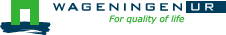

This notebook runs the PCSE/WOFOST model for Miscanthus using custom input data.

**Inputs:**
- Crop parameters: `miscanthus.yaml` (derived in `miscanthus_parameterization.ipynb`)
- Soil parameters: `soil_10110.soil` file (derived from Staringreeks 2018 via `soil_data_MvG.ipynb`)
- Weather data: `veenkampen_weather.xlsx` (MAQ station + AgERA5 gap-fill)
- Agromanagement: `misc_agro.yaml` (generated in parameterization notebook)
- Site parameters: defined inline below

%matplotlib inline


In [1]:
import sys
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import pcse
import numpy as np

print(f"Python version: {sys.version}")
print(f"PCSE version: {pcse.__version__}")

Python version: 3.13.12 | packaged by Anaconda, Inc. | (main, Feb 24 2026, 16:07:20) [Clang 20.1.8 ]
PCSE version: 6.0.12


## Define paths

In [ ]:
# Project root
project = Path.cwd().parents[1]
input_dir = project / "input_params"

crop_file    = input_dir / "miscanthus" / "miscanthus.yaml"
soil_file    = input_dir / "soil" / "soil_10110.soil"    
weather_file = input_dir / "weather" / "veenkampen_weather.xlsx"
agro_file    = input_dir / "agromanagement" / "misc_agro.yaml"

## Load crop parameters
Using `YAMLCropDataProvider` to read the Miscanthus YAML file generated in the parameterization notebook.

In [3]:
from pcse.input import YAMLCropDataProvider

cropdata = YAMLCropDataProvider(fpath=crop_file.parent, force_reload=True)
cropdata.set_active_crop("miscanthus", "miscanthus_sinensis")
print(cropdata)

Crop parameters loaded from: /Users/paulianoprescu/Projects/wofost_miscanthus/sinensis/miscanthus_calibration/input_params/miscanthus
YAMLCropDataProvider - current active crop 'miscanthus' with variety 'miscanthus_sinensis'
Available crop parameters:
 {'CO2EFFTB': [40.0, 0.0, 360.0, 1.0, 720.0, 1.0, 1000.0, 1.0, 2000.0, 1.0], 'CO2TRATB': [40.0, 0.0, 360.0, 1.0, 720.0, 0.74, 1000.0, 0.74, 2000.0, 0.74], 'CO2AMAXTB': [40.0, 0.0, 360.0, 1.0, 720.0, 1.0, 1000.0, 1.0, 2000.0, 1.0], 'TBASEM': 8.0, 'TEFFMX': 30.0, 'TSUMEM': 0, 'IDSL': 0, 'DLO': 1.0, 'DLC': 0.0, 'TSUM1': 1796.93, 'TSUM2': 203.068, 'DTSMTB': [0.0, 0.0, 8.0, 0.0, 35.0, 29.0, 45.0, 29.0], 'DVSI': 0, 'DVSEND': 2.0, 'VERNBASE': 14.0, 'VERNSAT': 70.0, 'VERNRTB': [-8.0, 0.0, -4.0, 0.0, 3.0, 1.0, 10.0, 1.0, 17.0, 0.0, 20.0, 0.0], 'TDWI': 600.0, 'RGRLAI': 0.05, 'SLATB': [0.0, 0.0009, 0.21, 0.0019, 0.29, 0.0012, 0.64, 0.0008, 1.0, 0.001, 2.0, 0.001], 'SPA': 0.0, 'SSATB': [0.0, 0.0, 2.0, 9.98e-07], 'SPAN': 75.0, 'TBASE': 10.0, 'KDIFTB':

## Load soil parameters

In [4]:
from pcse.input import CABOFileReader

soildata = CABOFileReader(soil_file)
print(soildata)

** Generated from Bodemkaart van Nederland
** Profielcode: 10110
** Topsoil sfu: B02 (Staringreeks 2018)
** Generated by: generate_wofost_soil.py
**
** SOIL PARAMTER FILE for use in PCSE
**
------------------------------------
SMW: 0.074 <class 'float'>
SMFCF: 0.312 <class 'float'>
SM0: 0.434 <class 'float'>
CRAIRC: 0.09 <class 'float'>
K0: 83.242 <class 'float'>
SOPE: 83.24 <class 'float'>
KSUB: 22.32 <class 'float'>
RDMSOL: 120 <class 'int'>
SOLNAM: 10110-B02 <class 'str'>
SMTAB: [-1.0, 0.434, 1.0, 0.421, 1.3, 0.405, 1.491, 0.388, 1.7, 0.361, 2.0, 0.312, 2.4, 0.244, 2.7, 0.198, 3.0, 0.161, 3.4, 0.123, 3.7, 0.101, 4.0, 0.083, 4.204, 0.074, 6.0, 0.033] <class 'list'>
CONTAB: [-1.0, 64.775, 1.0, 12.403, 1.3, 4.628, 1.491, 1.833, 1.7, 0.479, 2.0, 0.039, 2.4, 0.001, 2.7, 0.0, 3.0, 0.0, 3.4, 0.0, 3.7, 0.0, 4.0, 0.0, 4.204, 0.0, 6.0, 0.0] <class 'list'>



## Site parameters
These are not read from a file — they define initial conditions for the water balance and the atmospheric CO₂ concentration.

- **WAV**: Initial amount of water in total soil profile (cm). This is assumed at 50% between wilting point and field capacity


In [5]:
from pcse.input import WOFOST72SiteDataProvider

# Compute WAV as 50% between field capacity and wilting point
SMFCF = soildata["SMFCF"]
SMW   = soildata["SMW"]
RDI   = cropdata["RDI"]        # initial rooting depth (cm)
wav_init = 0.5 * (SMFCF - SMW) * RDI * 25   # mm
print(f"Initial WAV = {wav_init:.1f} mm  (50% between FC and WP)")

sitedata = WOFOST72SiteDataProvider(WAV=wav_init)

print(sitedata)

Initial WAV = 29.8 mm  (50% between FC and WP)
{'IFUNRN': 0, 'NOTINF': 0, 'SSI': 0.0, 'SSMAX': 0.0, 'WAV': 29.75, 'SMLIM': 0.4}


## Package all parameters

In [6]:
from pcse.base import ParameterProvider

parameters = ParameterProvider(cropdata=cropdata, soildata=soildata, sitedata=sitedata)

## Load weather data

In [7]:
from pcse.input import ExcelWeatherDataProvider

weatherdata = ExcelWeatherDataProvider(weather_file)
print(weatherdata)

Weather data provided by: ExcelWeatherDataProvider
--------Description---------
Weather data for:
Country: Netherlands
Station: Wageningen, Location Veenkampen
Description: Observed data from Station Veenkampen in Wageningen
Source: Meteorology and Air Quality Group, Wageningen University
Contact: None
----Site characteristics----
Elevation:    7.0
Latitude:  51.970
Longitude:  5.670
Data available for 2014-10-01 - 2026-01-01
Number of missing days: 0



## Load agromanagement

In [8]:
from pcse.input import YAMLAgroManagementReader

agromanagement = YAMLAgroManagementReader(agro_file)
print(agromanagement)

!!python/object/new:pcse.input.yaml_agro_loader.YAMLAgroManagementReader
listitems:
- 2014-10-01:
    CropCalendar:
      crop_end_date: 2015-12-30
      crop_end_type: harvest
      crop_name: miscanthus
      crop_start_date: 2015-01-01
      crop_start_type: emergence
      max_duration: null
      variety_name: miscanthus_sinensis
    StateEvents: null
    TimedEvents: null
- 2016-01-01:
    CropCalendar:
      crop_end_date: 2016-12-30
      crop_end_type: harvest
      crop_name: miscanthus
      crop_start_date: 2016-01-01
      crop_start_type: emergence
      max_duration: null
      variety_name: miscanthus_sinensis
    StateEvents: null
    TimedEvents: null
- 2017-01-01:
    CropCalendar:
      crop_end_date: 2017-12-30
      crop_end_type: harvest
      crop_name: miscanthus
      crop_start_date: 2017-01-01
      crop_start_type: emergence
      max_duration: null
      variety_name: miscanthus_sinensis
    StateEvents: null
    TimedEvents: null
- 2018-01-01:
    CropCal

## Run Both Simulations (WLP & PP)

PP  simulation: 2014-10-01 to 2025-01-01  (3746 days)
WLP simulation: 2014-10-01 to 2025-01-01  (3746 days)


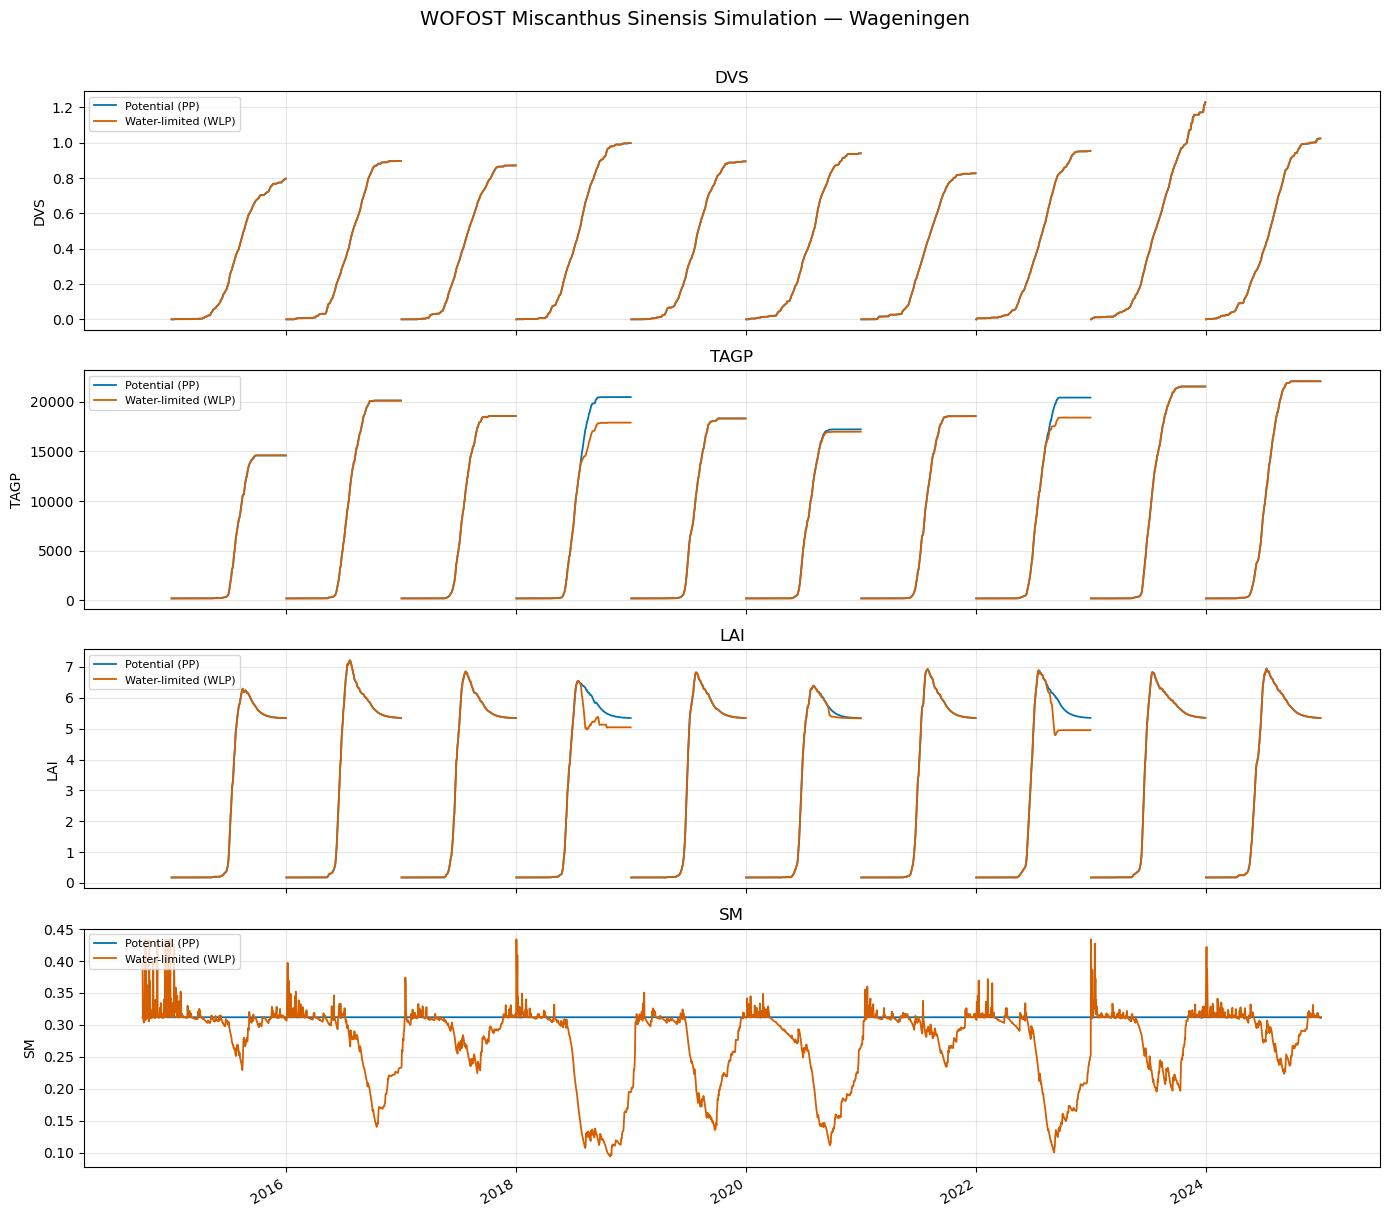

 Year   PP_t_ha  WLP_t_ha  Yield_gap_t_ha
 2014       NaN       NaN             NaN
 2015 14.596760 14.596760        0.000000
 2016 20.119686 20.119719       -0.000033
 2017 18.568058 18.568058        0.000000
 2018 20.471357 17.898911        2.572446
 2019 18.323098 18.313283        0.009815
 2020 17.223599 16.985110        0.238489
 2021 18.550035 18.550035        0.000000
 2022 20.420862 18.405957        2.014905
 2023 21.535613 21.535613        0.000000
 2024 22.064910 22.064910        0.000000
 2025       NaN       NaN             NaN
 Year  Observed_t_ha   PP_t_ha  WLP_t_ha  Error_PP  Error_WLP
 2015          11.24 14.596760 14.596760  3.356760   3.356760
 2016          17.42 20.119686 20.119719  2.699686   2.699719
 2017          15.33 18.568058 18.568058  3.238058   3.238058
 2018          15.90 20.471357 17.898911  4.571357   1.998911
 2019          12.99 18.323098 18.313283  5.333098   5.323283
 2020          14.25 17.223599 16.985110  2.973599   2.735110
 2021          11.02

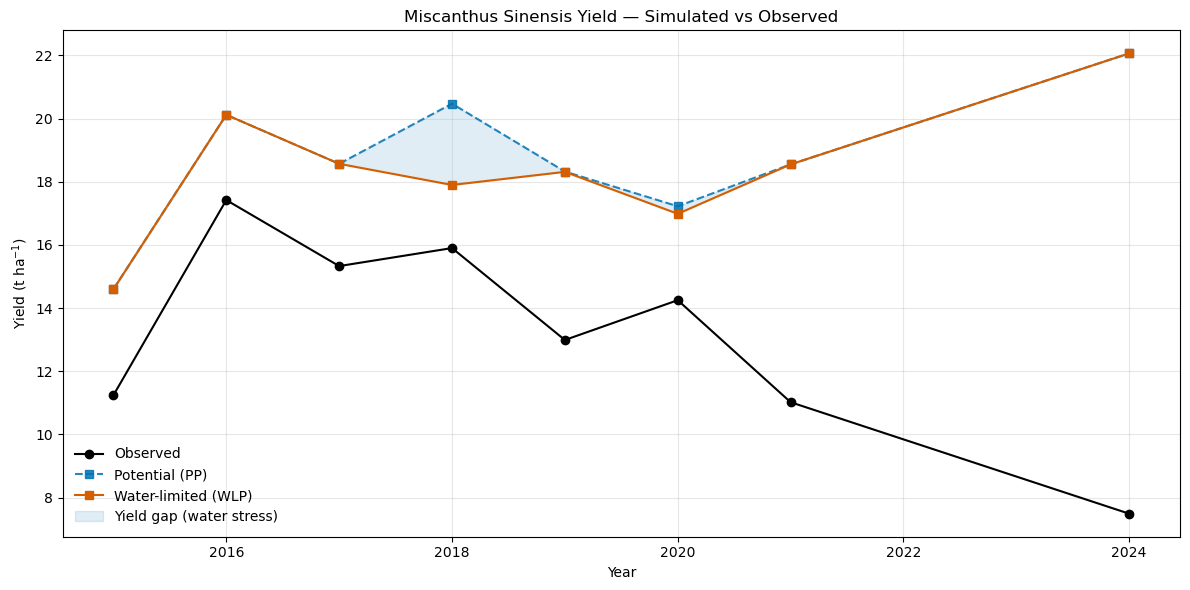

In [9]:
from matplotlib.pyplot import plot
from pcse.models import Wofost72_WLP_CWB, Wofost72_PP, Wofost81_WLP_CWB, Wofost81_PP

# Colors
PP_COLOR  = "#0072B2"   
WLP_COLOR = "#D55E00"   
OBS_COLOR = "#000000"   

# Potential Production (PP)
wofsim_pp = Wofost72_PP(parameters, weatherdata, agromanagement)
wofsim_pp.run_till_terminate()
df_pp = pd.DataFrame(wofsim_pp.get_output()).set_index("day")

# Water-Limited Production (WLP)
wofsim_wlp = Wofost72_WLP_CWB(parameters, weatherdata, agromanagement)
wofsim_wlp.run_till_terminate()
df_wlp = pd.DataFrame(wofsim_wlp.get_output()).set_index("day")

print(f"PP  simulation: {df_pp.index[0]} to {df_pp.index[-1]}  ({len(df_pp)} days)")
print(f"WLP simulation: {df_wlp.index[0]} to {df_wlp.index[-1]}  ({len(df_wlp)} days)")


# Visualize results (both runs)
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 12), sharex=True)

for var, ax in zip(["DVS", "TAGP", "LAI", "SM"], axes.flatten()):
    ax.plot(df_pp.index, df_pp[var], color=PP_COLOR, linewidth=1.3, label="Potential (PP)")
    ax.plot(df_wlp.index, df_wlp[var], color=WLP_COLOR, linewidth=1.3, label="Water-limited (WLP)")
    ax.set_ylabel(var)
    ax.set_title(var)
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(True, alpha=0.3)

fig.suptitle("WOFOST Miscanthus Sinensis Simulation — Wageningen", fontsize=14, y=1.01)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


# Quick yield summary per year (both runs)
df_pp["year"] = df_pp.index.map(lambda d: d.year)
df_wlp["year"] = df_wlp.index.map(lambda d: d.year)

yield_pp = df_pp.groupby("year")["TAGP"].max().reset_index()
yield_pp.columns = ["Year", "PP_TAGP_kg_ha"]
yield_pp["PP_t_ha"] = yield_pp["PP_TAGP_kg_ha"] / 1000

yield_wlp = df_wlp.groupby("year")["TAGP"].max().reset_index()
yield_wlp.columns = ["Year", "WLP_TAGP_kg_ha"]
yield_wlp["WLP_t_ha"] = yield_wlp["WLP_TAGP_kg_ha"] / 1000

yield_summary = yield_pp[["Year", "PP_t_ha"]].merge(yield_wlp[["Year", "WLP_t_ha"]], on="Year")
yield_summary["Yield_gap_t_ha"] = yield_summary["PP_t_ha"] - yield_summary["WLP_t_ha"]

print(yield_summary.to_string(index=False))


# Comparison with observed yields
observed_yields = [11.24, 17.42, 15.33, 15.90, 12.99, 14.25, 11.02, np.nan, np.nan, 7.49]
years_obs = list(range(2015, 2025))

comparison = yield_summary.copy()
obs_dict = dict(zip(years_obs, observed_yields))
comparison["Observed_t_ha"] = comparison["Year"].map(obs_dict)
comparison = comparison.dropna(subset=["Observed_t_ha"])

comparison["Error_WLP"] = comparison["WLP_t_ha"] - comparison["Observed_t_ha"]
comparison["Error_PP"] = comparison["PP_t_ha"] - comparison["Observed_t_ha"]

rmse_wlp = np.sqrt((comparison["Error_WLP"] ** 2).mean())
mae_wlp  = comparison["Error_WLP"].abs().mean()
bias_wlp = comparison["Error_WLP"].mean()

rmse_pp = np.sqrt((comparison["Error_PP"] ** 2).mean())
mae_pp  = comparison["Error_PP"].abs().mean()
bias_pp = comparison["Error_PP"].mean()

print(comparison[["Year", "Observed_t_ha", "PP_t_ha", "WLP_t_ha", "Error_PP", "Error_WLP"]].to_string(index=False))
print(f"--- Water-Limited ---")
print(f"RMSE:  {rmse_wlp:.2f} t/ha   MAE: {mae_wlp:.2f}   Bias: {bias_wlp:+.2f} ")
print(f"--- Potential ---")
print(f"RMSE:  {rmse_pp:.2f} t/ha   MAE: {mae_pp:.2f}   Bias: {bias_pp:+.2f}")


# Yield comparison plot (both runs vs observed)
fig, ax = plt.subplots(figsize=(12, 6))

years = comparison["Year"]
ax.plot(years, comparison["Observed_t_ha"], "o-", color=OBS_COLOR, label="Observed", linewidth=1.5)
ax.plot(years, comparison["PP_t_ha"], "s--", color=PP_COLOR, label="Potential (PP)", alpha=0.85)
ax.plot(years, comparison["WLP_t_ha"], "s-", color=WLP_COLOR, label="Water-limited (WLP)")
ax.fill_between(years, comparison["PP_t_ha"], comparison["WLP_t_ha"],
                color=PP_COLOR, alpha=0.12, label="Yield gap (water stress)")
ax.set_ylabel("Yield (t ha$^{-1}$)")
ax.set_title("Miscanthus Sinensis Yield — Simulated vs Observed")
ax.legend(frameon=False)
ax.grid(True, alpha=0.3)
ax.set_xlabel("Year")
fig.tight_layout()
plt.show()

In [10]:
# WLP error metrics restricted to 2015–2020
mask_2015_2020 = comparison["Year"].between(2015, 2020)
subset = comparison.loc[mask_2015_2020]

rmse_wlp_sub = np.sqrt((subset["Error_WLP"] ** 2).mean())
mae_wlp_sub  = subset["Error_WLP"].abs().mean()
bias_wlp_sub = subset["Error_WLP"].mean()

print(f"--- WLP, 2015–2020 (n = {len(subset)}) ---")
print(f"RMSE:  {rmse_wlp_sub:.2f} t/ha")
print(f"MAE:   {mae_wlp_sub:.2f} t/ha")
print(f"Bias:  {bias_wlp_sub:+.2f} t/ha")

--- WLP, 2015–2020 (n = 6) ---
RMSE:  3.39 t/ha
MAE:   3.23 t/ha
Bias:  +3.23 t/ha


## LaTeX

In [11]:
# COMBINED TABLE — Overleaf-ready format

def fmt(x):
    if pd.isna(x):
        return "--"
    return f"{x:.2f}"

# Make sure yield gap exists
if "Yield_gap_t_ha" not in comparison.columns:
    comparison["Yield_gap_t_ha"] = comparison["PP_t_ha"] - comparison["WLP_t_ha"]

rows = []

for _, r in comparison.iterrows():
    rows.append(
        f"{int(r['Year'])} & "
        f"{fmt(r['Observed_t_ha'])} & "
        f"{fmt(r['PP_t_ha'])} & "
        f"{fmt(r['WLP_t_ha'])} & "
        f"{fmt(r['Yield_gap_t_ha'])} & "
        f"{fmt(r['Error_PP'])} & "
        f"{fmt(r['Error_WLP'])} \\\\"
    )

latex_combined = "\n".join([
    r"\begin{table}[H]",
    r"\caption{Observed and simulated Miscanthus Sinensis yields (WLP \& PP, with yield gap difference stated) at Veenkampen with per-year errors and goodness-of-fit statistics (RMSE, MAE, Bias) for the potential (PP) and water-limited (WLP) runs (n = 8). All values in t\,ha$^{-1}$.}",
    r"\label{tab:wofost_combined}",
    r"\begin{tabular}{lcccccc}",
    r"\toprule",
    r"Year & Observed & PP & WLP & Yield Gap & Error PP & Error WLP \\",
    r"\midrule",
    *rows,
    rf"RMSE & -- & {rmse_pp:.2f} & {rmse_wlp:.2f} & -- & -- & -- \\",
    rf"MAE & -- & {mae_pp:.2f} & {mae_wlp:.2f} & -- & -- & -- \\",
    rf"Bias & -- & {bias_pp:.2f} & {bias_wlp:.2f} & -- & -- & -- \\",
    r"\bottomrule",
    r"\end{tabular}",
    r"\end{table}"
])

print(latex_combined)

\begin{table}[H]
\caption{Observed and simulated Miscanthus Sinensis yields (WLP \& PP, with yield gap difference stated) at Veenkampen with per-year errors and goodness-of-fit statistics (RMSE, MAE, Bias) for the potential (PP) and water-limited (WLP) runs (n = 8). All values in t\,ha$^{-1}$.}
\label{tab:wofost_combined}
\begin{tabular}{lcccccc}
\toprule
Year & Observed & PP & WLP & Yield Gap & Error PP & Error WLP \\
\midrule
2015 & 11.24 & 14.60 & 14.60 & 0.00 & 3.36 & 3.36 \\
2016 & 17.42 & 20.12 & 20.12 & -0.00 & 2.70 & 2.70 \\
2017 & 15.33 & 18.57 & 18.57 & 0.00 & 3.24 & 3.24 \\
2018 & 15.90 & 20.47 & 17.90 & 2.57 & 4.57 & 2.00 \\
2019 & 12.99 & 18.32 & 18.31 & 0.01 & 5.33 & 5.32 \\
2020 & 14.25 & 17.22 & 16.99 & 0.24 & 2.97 & 2.74 \\
2021 & 11.02 & 18.55 & 18.55 & 0.00 & 7.53 & 7.53 \\
2024 & 7.49 & 22.06 & 22.06 & 0.00 & 14.57 & 14.57 \\
RMSE & -- & 6.67 & 6.50 & -- & -- & -- \\
MAE & -- & 5.53 & 5.18 & -- & -- & -- \\
Bias & -- & 5.53 & 5.18 & -- & -- & -- \\
\bottomrule
\end{

In [12]:
# Comparison with AquaCrop simulation in same NUTS3 region (South-West Netherlands)
# AquaCrop yield is computed as an average of multiple years of simulation
aquacrop_yield = 8.1 # t/ha : miscanthus giganteus

# 2019-2023 average simulated yield
mask = comparison["Year"].between(2019, 2023)
avg_simulated_yield = comparison.loc[mask, "WLP_t_ha"].mean()

# 1-point comparison
diff = avg_simulated_yield - aquacrop_yield
pct_diff = 100 * diff / aquacrop_yield

print(f"WOFOST avg (2019-2023): {avg_simulated_yield:.2f} t/ha")
print(f"AquaCrop reference:     {aquacrop_yield:.2f} t/ha")
print(f"Absolute difference:    {diff:+.2f} t/ha")
print(f"Relative difference:    {pct_diff:+.1f}%")

WOFOST avg (2019-2023): 17.95 t/ha
AquaCrop reference:     8.10 t/ha
Absolute difference:    +9.85 t/ha
Relative difference:    +121.6%
